# Prudential Life Insurance Assessment

In [1]:
#!pip install lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
import time

## 1) Ucitavanje podataka

In [3]:
df = pd.read_csv('train.csv').iloc[:59000].copy()  # koristimo prvih 59k redova
df.head()

,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,0,0,0,0,0,0,8
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,0,0,0,0,0,0,8
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,0,0,0,0,0,0,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59000 entries, 0 to 58999
Columns: 128 entries, Id to Response
dtypes: float64(18), int64(109), object(1)
memory usage: 57.6+ MB


In [5]:
df.describe()

,Id,Product_Info_1,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
count,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,...,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000,59000.000000
mean,39252.749034,1.026407,24.416576,0.328964,2.006966,2.673559,1.043695,0.405598,0.707242,0.292551,...,0.056915,0.010102,0.045525,0.010712,0.007525,0.013746,0.008441,0.019898,0.054542,5.637407
std,22667.908275,0.160343,5.071284,0.282565,0.083173,0.739139,0.292315,0.197231,0.074252,0.089004,...,0.231683,0.099999,0.208455,0.102943,0.086423,0.116435,0.091485,0.139652,0.227087,2.456572
min,2.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,19646.750000,1.000000,26.000000,0.076923,2.000000,3.000000,1.000000,0.238806,0.654545,0.225941,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,39237.500000,1.000000,26.000000,0.230769,2.000000,3.000000,1.000000,0.402985,0.709091,0.288703,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,58836.250000,1.000000,26.000000,0.487179,2.000000,3.000000,1.000000,0.567164,0.763636,0.345188,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
max,78670.000000,2.000000,38.000000,1.000000,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000


In [6]:
df.shape

(59000, 128)

In [7]:
print(df['Response'].value_counts().sort_index())

Response
1     6165
2     6507
3     1006
4     1417
5     5396
6    11170
7     7970
8    19369
Name: count, dtype: int64


## 2) Brza analiza NA vrednosti

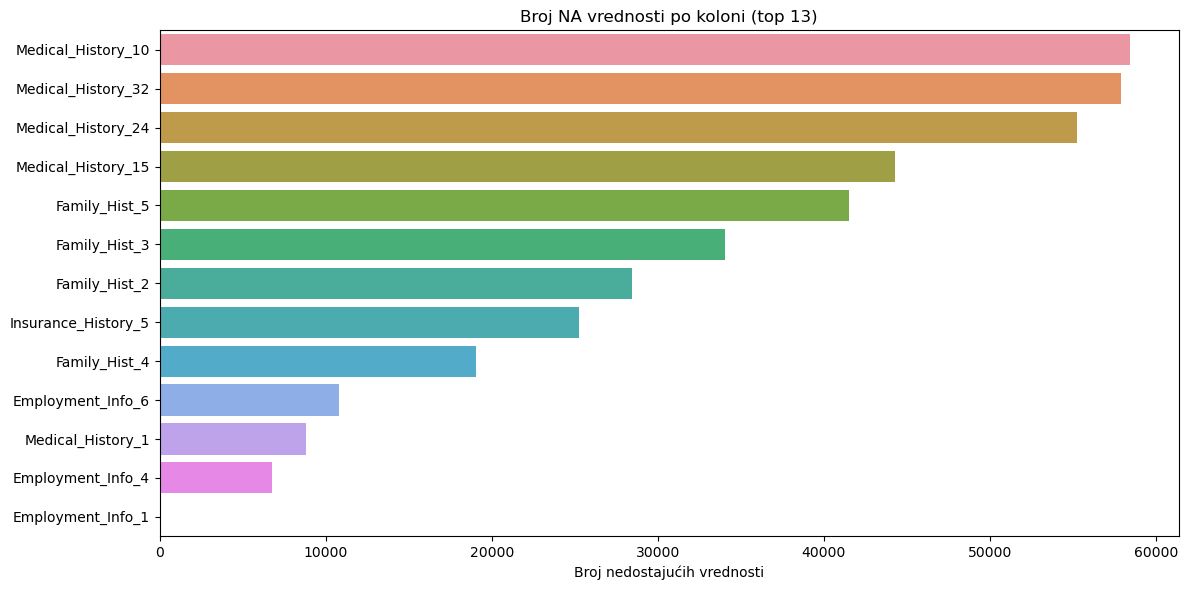

In [8]:
na_counts = df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
top_n = 13
sns.barplot(x=na_counts.iloc[:top_n].values, y=na_counts.iloc[:top_n].index)
plt.xlabel("Broj nedostajućih vrednosti")
plt.title("Broj NA vrednosti po koloni (top {})".format(top_n))
plt.tight_layout()
plt.show()

## 3) Priprema ciljne promenljive (collapse to binary)

In [9]:
df = df.copy()
df['Response_bin'] = df['Response'].apply(lambda x: 0 if x <= 4 else 1)
print("Distribucija cilja (binarno):")
print(display(df['Response_bin'].value_counts()))
print(display(df['Response_bin'].value_counts(normalize=True)))

Distribucija cilja (binarno):


Response_bin
1    43905
0    15095
Name: count, dtype: int64

None


Response_bin
1    0.744153
0    0.255847
Name: proportion, dtype: float64

None


## 4) Drop 10 najređih kolona (prema instrukciji)

In [10]:
cat_cols_all = [
 "Product_Info_1","Product_Info_2","Product_Info_3","Product_Info_5","Product_Info_6","Product_Info_7",
 "Employment_Info_2","Employment_Info_3","Employment_Info_5",
 "InsuredInfo_1","InsuredInfo_2","InsuredInfo_3","InsuredInfo_4","InsuredInfo_5","InsuredInfo_6","InsuredInfo_7",
 "Insurance_History_1","Insurance_History_2","Insurance_History_3","Insurance_History_4","Insurance_History_7","Insurance_History_8","Insurance_History_9",
 "Family_Hist_1","Medical_History_2", "Medical_History_3", "Medical_History_4", "Medical_History_5",  
 "Medical_History_6", "Medical_History_7", "Medical_History_8", "Medical_History_9",  
 "Medical_History_11", "Medical_History_12", "Medical_History_13", "Medical_History_14",  
 "Medical_History_16", "Medical_History_17", "Medical_History_18", "Medical_History_19",  
 "Medical_History_20", "Medical_History_21", "Medical_History_22", "Medical_History_23",  
 "Medical_History_25", "Medical_History_26", "Medical_History_27", "Medical_History_28",  
 "Medical_History_29", "Medical_History_30", "Medical_History_31", "Medical_History_33",  
 "Medical_History_34", "Medical_History_35", "Medical_History_36", "Medical_History_37",  
 "Medical_History_38", "Medical_History_39", "Medical_History_40", "Medical_History_41"
]

cat_cols_all = [c for c in cat_cols_all if c in df.columns]

In [11]:
# Računamo procent nedostajućih po kategorijskoj koloni
cat_na_frac = (df[cat_cols_all].isna().sum() / len(df)).sort_values(ascending=False)
print("\nKategorijske kolone po procentu NA:")
display(cat_na_frac)


Kategorijske kolone po procentu NA:


Product_Info_1         0.0
Product_Info_2         0.0
Medical_History_11     0.0
Medical_History_12     0.0
Medical_History_13     0.0
Medical_History_14     0.0
Medical_History_16     0.0
Medical_History_17     0.0
Medical_History_18     0.0
Medical_History_19     0.0
Medical_History_20     0.0
Medical_History_21     0.0
Medical_History_22     0.0
Medical_History_23     0.0
Medical_History_25     0.0
Medical_History_26     0.0
Medical_History_27     0.0
Medical_History_28     0.0
Medical_History_29     0.0
Medical_History_30     0.0
Medical_History_31     0.0
Medical_History_33     0.0
Medical_History_34     0.0
Medical_History_35     0.0
Medical_History_36     0.0
Medical_History_37     0.0
Medical_History_38     0.0
Medical_History_39     0.0
Medical_History_40     0.0
Medical_History_9      0.0
Medical_History_8      0.0
Medical_History_7      0.0
InsuredInfo_6          0.0
Product_Info_3         0.0
Product_Info_5         0.0
Product_Info_6         0.0
Product_Info_7         0.0
E

Posto ni jedna od njih nema NA vrednost, ostavicemo ih

## 5) Konstrukcija novih atributa (feature engineering)

In [12]:
# 5.1 Medical_Keyword_1-48 -> sum (broj 'keyword' zastavica)
med_kw_cols = [c for c in df.columns if c.startswith("Medical_Keyword_")]
if len(med_kw_cols) > 0:
    df['med_keyword_sum'] = df[med_kw_cols].sum(axis=1, skipna=True)
    print("Dodata med_keyword_sum (suma od {} kolona)".format(len(med_kw_cols)))

Dodata med_keyword_sum (suma od 48 kolona)


In [13]:
# 5.2 Medical_History_1-41 -> sum (gde je smisleno)
med_hist_cols = [c for c in df.columns if c.startswith("Medical_History_")]
# Mnogi su binarni/indikatori; sumiraćemo (nan tretiramo kao 0 za sumu)
if len(med_hist_cols) > 0:
    df['med_history_sum'] = df[med_hist_cols].fillna(0).sum(axis=1)
    print("Dodata med_history_sum (suma od {} kolona)".format(len(med_hist_cols)))

Dodata med_history_sum (suma od 41 kolona)


In [14]:
# 5.3 Family_Hist_ columns sum
family_hist_cols = [c for c in df.columns if c.startswith("Family_Hist_")]
if len(family_hist_cols) > 0:
    df['family_hist_sum'] = df[family_hist_cols].fillna(0).sum(axis=1)
    print("Dodata family_hist_sum (suma od {} kolona)".format(len(family_hist_cols)))

Dodata family_hist_sum (suma od 5 kolona)


In [15]:
# 5.4 BMI * Ins_Age (interakcija) i Ht/Wt ratio
if 'BMI' in df.columns and 'Ins_Age' in df.columns:
    df['bmi_age'] = df['BMI'] * df['Ins_Age']
if 'Ht' in df.columns and 'Wt' in df.columns:
    # izbegavamo deljenje nulom
    df['height_weight_ratio'] = df['Ht'] / (df['Wt'].replace(0, np.nan))

In [16]:
# 5.5 broj nedostajućih vrednosti po redu (može biti signal)
df['num_missing_row'] = df.isna().sum(axis=1)

In [17]:
# Provera da li se dobro sacuvalo
print("\nNove kolone dodate (ako postoje):", [c for c in df.columns if c.startswith(('med_', 'family_', 'bmi_', 'height_weight_ratio', 'num_missing'))][:20])


Nove kolone dodate (ako postoje): ['med_keyword_sum', 'med_history_sum', 'family_hist_sum', 'bmi_age', 'height_weight_ratio', 'num_missing_row']


## 6) Podela podataka (trening i test)

In [18]:
target_col = 'Response_bin'
X = df.drop(columns=['Response', 'Response_bin','Id']) 
y = df[target_col]

In [19]:
# Stratify split radi balansa klasa u train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nVeličine split-a:", X_train.shape, X_test.shape, y_train.value_counts(normalize=True).to_dict())


Veličine split-a: (47200, 132) (11800, 132) {1: 0.7441525423728813, 0: 0.25584745762711864}


## 7) Identifikacija numeričkih i kategorijskih kolona nakon feature engineering

In [20]:
# Brojna polja su navedena kao "continuous" u opisu dataset-a; ali uzimamo automatski
all_cols = X_train.columns.tolist()

In [21]:
# Kategoricke su preostale nominalne (ali neki medical_history su numerički, pa su u numeric)
# Ako neke kolone treba eksplicitno tretirati kao kategoricke
# Uzimamo kao kategoricke one koji su tipa object ili bili u initial cat list i postoje u X
cat_cols_auto = X_train.select_dtypes(include=['object','category']).columns.tolist()
# dodamo one iz originalne liste cat_cols koji su još u X_train i datoteci
for c in cat_cols_all:
    if c in X_train.columns and c not in cat_cols_auto:
        cat_cols_auto.append(c)

cat_cols_auto

['Product_Info_2',
 'Product_Info_1',
 'Product_Info_3',
 'Product_Info_5',
 'Product_Info_6',
 'Product_Info_7',
 'Employment_Info_2',
 'Employment_Info_3',
 'Employment_Info_5',
 'InsuredInfo_1',
 'InsuredInfo_2',
 'InsuredInfo_3',
 'InsuredInfo_4',
 'InsuredInfo_5',
 'InsuredInfo_6',
 'InsuredInfo_7',
 'Insurance_History_1',
 'Insurance_History_2',
 'Insurance_History_3',
 'Insurance_History_4',
 'Insurance_History_7',
 'Insurance_History_8',
 'Insurance_History_9',
 'Family_Hist_1',
 'Medical_History_2',
 'Medical_History_3',
 'Medical_History_4',
 'Medical_History_5',
 'Medical_History_6',
 'Medical_History_7',
 'Medical_History_8',
 'Medical_History_9',
 'Medical_History_11',
 'Medical_History_12',
 'Medical_History_13',
 'Medical_History_14',
 'Medical_History_16',
 'Medical_History_17',
 'Medical_History_18',
 'Medical_History_19',
 'Medical_History_20',
 'Medical_History_21',
 'Medical_History_22',
 'Medical_History_23',
 'Medical_History_25',
 'Medical_History_26',
 'Medical_

In [22]:
X_train[cat_cols_auto].dtypes

Product_Info_2         object
Product_Info_1          int64
Product_Info_3          int64
Product_Info_5          int64
Product_Info_6          int64
Product_Info_7          int64
Employment_Info_2       int64
Employment_Info_3       int64
Employment_Info_5       int64
InsuredInfo_1           int64
InsuredInfo_2           int64
InsuredInfo_3           int64
InsuredInfo_4           int64
InsuredInfo_5           int64
InsuredInfo_6           int64
InsuredInfo_7           int64
Insurance_History_1     int64
Insurance_History_2     int64
Insurance_History_3     int64
Insurance_History_4     int64
Insurance_History_7     int64
Insurance_History_8     int64
Insurance_History_9     int64
Family_Hist_1           int64
Medical_History_2       int64
Medical_History_3       int64
Medical_History_4       int64
Medical_History_5       int64
Medical_History_6       int64
Medical_History_7       int64
Medical_History_8       int64
Medical_History_9       int64
Medical_History_11      int64
Medical_Hi

In [23]:
X_train[cat_cols_auto] = X_train[cat_cols_auto].astype('object')
X_test[cat_cols_auto] = X_test[cat_cols_auto].astype('object')

In [24]:
X_train[cat_cols_auto].dtypes

Product_Info_2         object
Product_Info_1         object
Product_Info_3         object
Product_Info_5         object
Product_Info_6         object
Product_Info_7         object
Employment_Info_2      object
Employment_Info_3      object
Employment_Info_5      object
InsuredInfo_1          object
InsuredInfo_2          object
InsuredInfo_3          object
InsuredInfo_4          object
InsuredInfo_5          object
InsuredInfo_6          object
InsuredInfo_7          object
Insurance_History_1    object
Insurance_History_2    object
Insurance_History_3    object
Insurance_History_4    object
Insurance_History_7    object
Insurance_History_8    object
Insurance_History_9    object
Family_Hist_1          object
Medical_History_2      object
Medical_History_3      object
Medical_History_4      object
Medical_History_5      object
Medical_History_6      object
Medical_History_7      object
Medical_History_8      object
Medical_History_9      object
Medical_History_11     object
Medical_Hi

In [25]:
# Smatramo za numeričke one koji su numeric tipa
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

In [26]:
# Pronađi dummy kolone (Medical_Keyword_*)
dummy_cols = [col for col in numeric_cols if "Medical_Keyword" in col]

# Ukloni ih iz numeric_cols
numeric_cols = [col for col in numeric_cols if col not in dummy_cols]

# Prikaz koje su kolone izbačene
print("Izbačene dummy kolone (Medical_Keyword_*):")
print(f"Ukupno izbačeno: {len(dummy_cols)} kolona.")

Izbačene dummy kolone (Medical_Keyword_*):
Ukupno izbačeno: 48 kolona.


In [27]:
X_train[numeric_cols].dtypes

Product_Info_4         float64
Ins_Age                float64
Ht                     float64
Wt                     float64
BMI                    float64
Employment_Info_1      float64
Employment_Info_4      float64
Employment_Info_6      float64
Insurance_History_5    float64
Family_Hist_2          float64
Family_Hist_3          float64
Family_Hist_4          float64
Family_Hist_5          float64
Medical_History_1      float64
Medical_History_10     float64
Medical_History_15     float64
Medical_History_24     float64
Medical_History_32     float64
med_keyword_sum          int64
med_history_sum        float64
family_hist_sum        float64
bmi_age                float64
height_weight_ratio    float64
num_missing_row          int64
dtype: object

In [28]:
print("\nPrimeri numeričkih kolona (count={}): {}".format(len(numeric_cols), numeric_cols[:20]))
print("Primeri kategorijskih kolona (count={}): {}".format(len(cat_cols_auto), cat_cols_auto[:30]))


Primeri numeričkih kolona (count=24): ['Product_Info_4', 'Ins_Age', 'Ht', 'Wt', 'BMI', 'Employment_Info_1', 'Employment_Info_4', 'Employment_Info_6', 'Insurance_History_5', 'Family_Hist_2', 'Family_Hist_3', 'Family_Hist_4', 'Family_Hist_5', 'Medical_History_1', 'Medical_History_10', 'Medical_History_15', 'Medical_History_24', 'Medical_History_32', 'med_keyword_sum', 'med_history_sum']
Primeri kategorijskih kolona (count=60): ['Product_Info_2', 'Product_Info_1', 'Product_Info_3', 'Product_Info_5', 'Product_Info_6', 'Product_Info_7', 'Employment_Info_2', 'Employment_Info_3', 'Employment_Info_5', 'InsuredInfo_1', 'InsuredInfo_2', 'InsuredInfo_3', 'InsuredInfo_4', 'InsuredInfo_5', 'InsuredInfo_6', 'InsuredInfo_7', 'Insurance_History_1', 'Insurance_History_2', 'Insurance_History_3', 'Insurance_History_4', 'Insurance_History_7', 'Insurance_History_8', 'Insurance_History_9', 'Family_Hist_1', 'Medical_History_2', 'Medical_History_3', 'Medical_History_4', 'Medical_History_5', 'Medical_History_

# 8) Razdvajanje kategorija po kardinalnosti i frekvencijsko kodiranje visokokardinalnih

In [29]:
# Definišemo 'low_card_cols' za OneHot (unique <= 10) i 'high_card_cols' za freq encoding
low_card_cols = []
high_card_cols = []
for c in cat_cols_auto:
    nuni = X_train[c].nunique(dropna=True)
    if nuni <= 10:
        low_card_cols.append(c)
    else:
        high_card_cols.append(c)

print("\nLow-cardinality (onehot):", low_card_cols[:5], "...total:", len(low_card_cols))
print("High-cardinality (freq-encode):", high_card_cols[:20], "... total:", len(high_card_cols))


Low-cardinality (onehot): ['Product_Info_1', 'Product_Info_5', 'Product_Info_6', 'Product_Info_7', 'Employment_Info_3'] ...total: 55
High-cardinality (freq-encode): ['Product_Info_2', 'Product_Info_3', 'Employment_Info_2', 'InsuredInfo_3', 'Medical_History_2'] ... total: 5


In [30]:
# FREKVENCIJSKO kodiranje za high_card_cols (mapa kategori -> frekvencija u treningu)
def apply_freq_encoding(train_df, test_df, cols):
    """Vrati kopije sa dodatim freq-encoded kolonama (colname+'_freq')"""
    train = train_df.copy()
    test = test_df.copy()
    for c in cols:
        vc = train[c].value_counts(dropna=False)
        freq_map = vc / len(train)
        new_name = c + "_freq"
        train[new_name] = train[c].map(freq_map).fillna(0.0)
        test[new_name] = test[c].map(freq_map).fillna(0.0)
    return train, test

In [31]:
# Napravi kopije X_train/X_test i primeni freq encoding
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
if len(high_card_cols) > 0:
    X_train_enc, X_test_enc = apply_freq_encoding(X_train_enc, X_test_enc, high_card_cols)
    # high-card frequency columns su sada numeričke
    high_card_freq_cols = [c + "_freq" for c in high_card_cols]
else:
    high_card_freq_cols = []

In [32]:
# Ne zaboravimo da originalne high-card kolone još uvek postoje (OneHot ne koristimo za njih),
# ali ćemo ih izostaviti iz daljeg ColumnTransformer-a (ili ih možemo zadržati ako želimo)
# U našem slučaju nećemo koristiti originalne high-card kolone (ostavljamo samo freq kolone)
# Dakle uklonimo originalne high-card kolone iz skupa koji ide u OneHot
for c in high_card_cols:
    if c in low_card_cols:
        low_card_cols.remove(c)

## 9) Sastavljanje listi kolona za ColumnTransformer

In [33]:
# Numeričke kolone - uključimo: originalne numeric + freq colse
# Pažljivo: neka numeric kolone imaju NaN -> imputer će popuniti
numeric_cols_final = list(set(numeric_cols + high_card_freq_cols))
# Ukloni one koji nisu u df
numeric_cols_final = [c for c in numeric_cols_final if c in X_train_enc.columns]

# Categorical low-card (OneHot) - samo one koje postoje
low_card_cols = [c for c in low_card_cols if c in X_train_enc.columns]

print("\nNumeric final count:", len(numeric_cols_final))
print("Low-card final count:", len(low_card_cols))
print("High-card freq cols (numeric):", high_card_freq_cols[:10])


Numeric final count: 29
Low-card final count: 55
High-card freq cols (numeric): ['Product_Info_2_freq', 'Product_Info_3_freq', 'Employment_Info_2_freq', 'InsuredInfo_3_freq', 'Medical_History_2_freq']


# 10) ColumnTransformer: imputacija + onehot + scaling

In [34]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_cols_final),
        ('cat', cat_pipeline, low_card_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

In [35]:
# Fit transform samo na X_train_enc; kasnije transform na X_test_enc
print("\nFitujem preprocessor na trening podacima...")
X_train_pre = preprocessor.fit_transform(X_train_enc)
X_test_pre  = preprocessor.transform(X_test_enc)


Fitujem preprocessor na trening podacima...


In [36]:
# Dohvati izvodljiva imena kolona nakon transformacije (da bismo mogli da radimo selekciju)
# Funkcija za dobijanje feature names iz ColumnTransformer-a (skloni complexity)
def get_feature_names_from_column_transformer(ct, numeric_cols, low_card_cols):
    feature_names = []
    # numeric pipeline -> output names su isti kao numeric_cols
    feature_names.extend(numeric_cols)
    # cat pipeline -> get onehot names
    if 'cat' in dict(ct.named_transformers_):
        cat_pipe = ct.named_transformers_['cat']
        if hasattr(cat_pipe.named_steps['onehot'], "get_feature_names_out"):
            oh_names = cat_pipe.named_steps['onehot'].get_feature_names_out(low_card_cols)
            feature_names.extend(list(oh_names))
        else:
            # fallback
            feature_names.extend(low_card_cols)
    return feature_names

In [37]:
# Napravi feature_names (koristimo numeric_cols_final i low_card_cols)
feature_names = []
# numeric outputs: after imputer+scaler imena ostaju numerička
feature_names.extend(numeric_cols_final)
# cat outputs:
if len(low_card_cols) > 0:
    oh = preprocessor.named_transformers_['cat'].named_steps['onehot']
    oh_names = oh.get_feature_names_out(low_card_cols)
    feature_names.extend(list(oh_names))

print("Broj izlaznih feature-a posle preprocesiranja:", X_train_pre.shape[1], "-> broj imena:", len(feature_names))

Broj izlaznih feature-a posle preprocesiranja: 178 -> broj imena: 178


In [38]:
# sanity check
if X_train_pre.shape[1] != len(feature_names):
    print("UPOZORENJE: broj imena se ne poklapa sa brojem kolona. Imena će biti generisana generički.")
    feature_names = [f"f_{i}" for i in range(X_train_pre.shape[1])]

In [39]:
# Pretvori transformisane matricu u DataFrame radi lakše manipulacije/inspect
X_train_pre_df = pd.DataFrame(X_train_pre, columns=feature_names)
X_test_pre_df = pd.DataFrame(X_test_pre, columns=feature_names)

## 11) Feature selection (embedded-like, manuelno) - RandomForest importances

In [40]:
# Napravi brz RandomForest na celom predprocesiranom skupu da dobijemo važnosti
print("\nTreniram RandomForest radi procene važnosti (za selekciju atributa)...")
rf_for_feat = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1, class_weight='balanced')
rf_for_feat.fit(X_train_pre_df, y_train)


Treniram RandomForest radi procene važnosti (za selekciju atributa)...


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


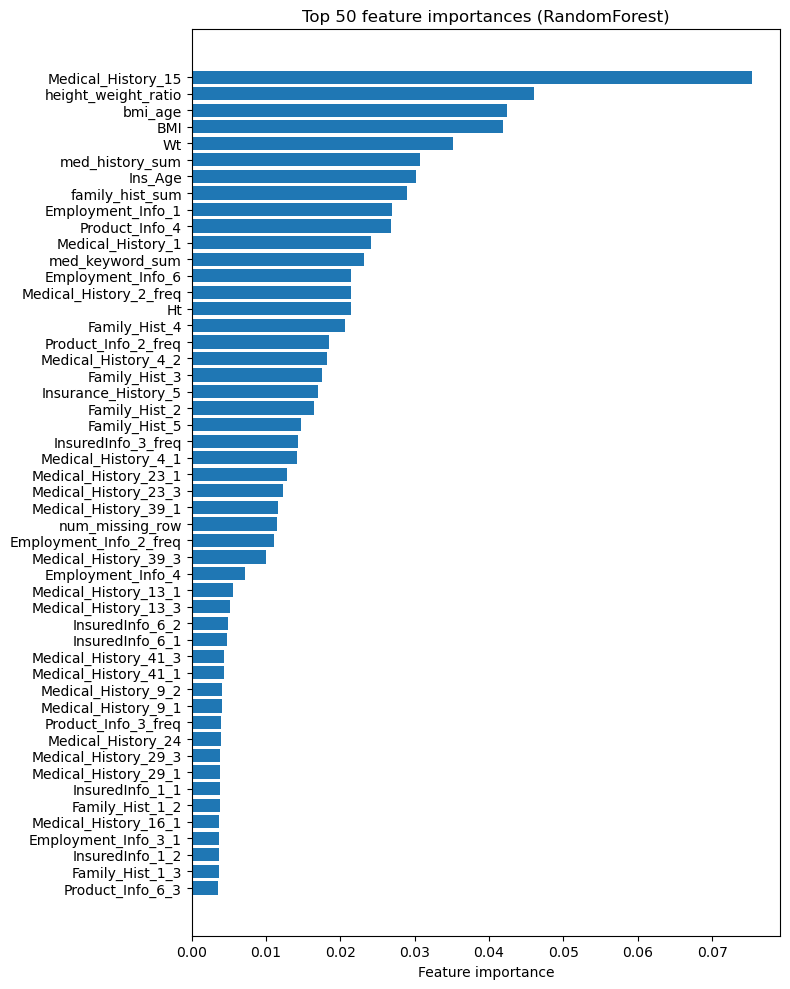

In [41]:
importances = rf_for_feat.feature_importances_
feat_imp = pd.Series(importances, index=X_train_pre_df.columns).sort_values(ascending=False)

top_n = min(50, feat_imp.size)
top_feat = feat_imp.head(top_n)

# ispiši top N u konzolu
#print(f"Top {top_n} feature-a:\n")
#print(top_feat.to_string())

plt.figure(figsize=(8, max(4, top_n*0.2)))
plt.barh(y=range(top_n), width=top_feat.values[::-1])
plt.yticks(range(top_n), labels=top_feat.index[::-1])
plt.xlabel('Feature importance')
plt.title(f'Top {top_n} feature importances (RandomForest)')
plt.tight_layout()
plt.show()

#display(feat_imp.head(40))

In [42]:
# Strategija selekcije: uzmemo top_k feature-a.
# Možeš promeniti top_k po želji; ovde biram top 50 ili manje ako nema toliko.
top_k = min(50, len(feat_imp))
selected_feats = feat_imp.head(top_k).index.tolist()
print("\nIzabrano top_k = {} feature-a za dalje modele.".format(top_k))


Izabrano top_k = 50 feature-a za dalje modele.


In [43]:
# Redukuj train/test matricu
X_train_sel = X_train_pre_df[selected_feats].copy()
X_test_sel  = X_test_pre_df[selected_feats].copy()

print("Veličine nakon selekcije:", X_train_sel.shape, X_test_sel.shape)

Veličine nakon selekcije: (47200, 50) (11800, 50)


## 12) Modeli: RandomForest, LogisticRegression i LGBMClassifier + CV + GridSearch

In [44]:
# Parametri za grid
param_grid_rf = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 3]
}

param_grid_log = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l2", "l1"],      
    "solver": ["saga"],
    "max_iter": [2000]
}

param_grid_lgb = {
    "n_estimators": [100, 300],
    "num_leaves": [31, 63],
    "learning_rate": [0.05, 0.1],
    "max_depth": [-1, 10, 20],
}

In [45]:
# Stratified CV (koristi se i unutar GridSearch)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [46]:
# Random Forest GridSearch
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [47]:
print("\nPokrecem GridSearch za RandomForest (stratified CV)...")
gs_rf.fit(X_train_sel, y_train)

print("\nNajbolji parametri (RF):", gs_rf.best_params_)
print("Best CV f1 (RF):", gs_rf.best_score_)


Pokrecem GridSearch za RandomForest (stratified CV)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Najbolji parametri (RF): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV f1 (RF): 0.8901278140398959


In [48]:
# Logistic Regression GridSearch
# Napomena: koristimo solver='saga' u grid, pa LogisticRegression mora imati multi_class='auto' i max_iter dovoljno veliki
log = LogisticRegression(class_weight='balanced', random_state=0)

gs_log = GridSearchCV(
    estimator=log,
    param_grid=param_grid_log,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [49]:
print("\nPokrecem GridSearch za LogisticRegression (stratified CV)...")
gs_log.fit(X_train_sel, y_train)

print("\nNajbolji parametri (Logistic):", gs_log.best_params_)
print("Best CV f1 (Logistic):", gs_log.best_score_)


Pokrecem GridSearch za LogisticRegression (stratified CV)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Najbolji parametri (Logistic): {'C': 0.01, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'saga'}
Best CV f1 (Logistic): 0.8078498270233204


In [50]:
lgb = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

gs_lgb = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid_lgb,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [51]:
print("\nPokrecem GridSearch za LightGBM (stratified CV)...")
gs_lgb.fit(X_train_sel, y_train)

print("Najbolji parametri (LGBM):", gs_lgb.best_params_)
print("Best CV f1 (LGBM):", gs_lgb.best_score_)


Pokrecem GridSearch za LightGBM (stratified CV)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Number of positive: 35124, number of negative: 12076
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3898
[LightGBM] [Info] Number of data points in the train set: 47200, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Najbolji parametri (LGBM): {'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 300, 'num_leaves': 63}
Best CV f1 (LGBM): 0.8628193959302555


In [52]:
# Fit najboljih modela na ceo trening (sa best params)
best_rf = gs_rf.best_estimator_
best_log = gs_log.best_estimator_
best_lgb = gs_lgb.best_estimator_

best_rf.fit(X_train_sel, y_train)
best_log.fit(X_train_sel, y_train)
best_lgb.fit(X_train_sel, y_train)

[LightGBM] [Info] Number of positive: 35124, number of negative: 12076
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3898
[LightGBM] [Info] Number of data points in the train set: 47200, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,20
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 13) Evaluacija modela

In [53]:
# Predikcije i evaluacija na test skupu
y_pred_rf = best_rf.predict(X_test_sel)
y_proba_rf = best_rf.predict_proba(X_test_sel)[:, 1] if hasattr(best_rf, "predict_proba") else None

y_pred_log = best_log.predict(X_test_sel)
y_proba_log = best_log.predict_proba(X_test_sel)[:, 1] if hasattr(best_log, "predict_proba") else None

y_pred_lgb = best_lgb.predict(X_test_sel)
y_proba_lgb = best_lgb.predict_proba(X_test_sel)[:, 1] if hasattr(best_lgb, "predict_proba") else None

In [54]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print("\n--- Evaluacija modela:", name, "---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    if y_proba is not None:
        try:
            print("ROC AUC:", roc_auc_score(y_true, y_proba))
        except Exception as e:
            print("ROC AUC: nije moguće (error):", e)
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification report:\n", classification_report(y_true, y_pred, digits=4))


In [55]:
evaluate_model("RandomForest (best from GridSearch)", y_test, y_pred_rf, y_proba_rf)
evaluate_model("LogisticRegression (best from GridSearch)", y_test, y_pred_log, y_proba_log)
evaluate_model("LightGBM (best from GridSearch)", y_test, y_pred_lgb, y_proba_lgb)


--- Evaluacija modela: RandomForest (best from GridSearch) ---
Accuracy: 0.8233050847457627
F1-score: 0.8908091123330715
ROC AUC: 0.8101758935616321
Confusion matrix:
 [[1210 1809]
 [ 276 8505]]
Classification report:
               precision    recall  f1-score   support

           0     0.8143    0.4008    0.5372      3019
           1     0.8246    0.9686    0.8908      8781

    accuracy                         0.8233     11800
   macro avg     0.8194    0.6847    0.7140     11800
weighted avg     0.8220    0.8233    0.8003     11800


--- Evaluacija modela: LogisticRegression (best from GridSearch) ---
Accuracy: 0.7290677966101695
F1-score: 0.8043331905257359
ROC AUC: 0.7856374382356679
Confusion matrix:
 [[2032  987]
 [2210 6571]]
Classification report:
               precision    recall  f1-score   support

           0     0.4790    0.6731    0.5597      3019
           1     0.8694    0.7483    0.8043      8781

    accuracy                         0.7291     11800
   macro 

## 14) Kratki zaključci i šta dalje

In [57]:
print("\nZaključci i preporuke:")
print("- U kodu je IMPUTER uklopljen u preprocessor (SimpleImputer), tako da modeli ne dobijaju NaN.")
print("- Selektovali smo top {} feature-a na bazi RandomForest važnosti (embedded-pristup).".format(top_k))
print("- Za ovaj dataset embedded (tree-based) selekcija je često dobar izbor jer hvata nelinearne interakcije i tolerance na skaliranje / enkodiranje.")
print("- Alternativa selekciji: wrapper (RFE) bi bila mnogo skuplja računarski; filter metode (mutual_info) su brže, ali zanemaruju interakcije. Zbog brojnih feature-a i potencijalnih nelinearnih relacija embedded (RF) je praktičan i robustan izbor.")
print("- Dalje poboljšanje: probati strojeve gradijentnog boostinga (HistGradientBoostingClassifier ili CatBoost), finu obradu kategorijskih varijabli, target-encoding sa pravilnim leakage-safe KFold pristupom, hyperparametarski search (RandomizedSearchCV; stedi vreme).")


Zaključci i preporuke:
- U kodu je IMPUTER uklopljen u preprocessor (SimpleImputer), tako da modeli ne dobijaju NaN.
- Selektovali smo top 50 feature-a na bazi RandomForest važnosti (embedded-pristup).
- Za ovaj dataset embedded (tree-based) selekcija je često dobar izbor jer hvata nelinearne interakcije i tolerance na skaliranje / enkodiranje.
- Alternativa selekciji: wrapper (RFE) bi bila mnogo skuplja računarski; filter metode (mutual_info) su brže, ali zanemaruju interakcije. Zbog brojnih feature-a i potencijalnih nelinearnih relacija embedded (RF) je praktičan i robustan izbor.
- Dalje poboljšanje: probati strojeve gradijentnog boostinga (HistGradientBoostingClassifier ili CatBoost), finu obradu kategorijskih varijabli, target-encoding sa pravilnim leakage-safe KFold pristupom, hyperparametarski search (RandomizedSearchCV; stedi vreme).
